# 06 Ensemble / stacking — dataset_2 (centrality + embeddings)

Combines the two approaches' threshold predictions per dataset. For each `p`: a **stacked** meta-learner
(LinearRegression on the two base predictions, trained on the **validation** split, evaluated on **test**)
and a simple **average** ensemble. Base predictions come from the per-dataset `*_threshold` notebooks.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / 'src').exists() and (p / 'requirements.txt').exists():
            return p
    raise FileNotFoundError('Project root not found.')

PROJECT_ROOT = find_project_root()
PRED = PROJECT_ROOT / 'src' / 'data' / 'predictions'
OUT  = PRED / 'dataset_2' / 'ensemble'; OUT.mkdir(parents=True, exist_ok=True)
TC = 'log_systemic_risk_label'
DATASETS = ['dataset_2']
P_LIST = ['p0', 'p5', 'p10', 'p15', 'p20', 'p25', 'p30', 'p35', 'p40']
rmse = lambda a, b: mean_squared_error(a, b) ** 0.5

## Build stacked + average ensembles per dataset / p

In [2]:
rows, all_preds = [], []
for ds in DATASETS:
    cen = pd.read_csv(PRED / ds / 'centrality_threshold' / 'predictions.csv')
    emb = pd.read_csv(PRED / ds / 'embedding_threshold' / 'predictions.csv')
    for p in P_LIST:
        c = cen[cen.p == p][['bank_id', 'split', TC, 'prediction']].rename(columns={'prediction': 'centrality_pred'})
        e = emb[emb.p == p][['bank_id', 'split', 'prediction']].rename(columns={'prediction': 'embedding_pred'})
        m = c.merge(e, on=['bank_id', 'split'], how='inner')
        val, test = m[m.split == 'validation'], m[m.split == 'test'].copy()
        stk = LinearRegression().fit(val[['centrality_pred', 'embedding_pred']], val[TC])
        test['average_pred'] = test[['centrality_pred', 'embedding_pred']].mean(axis=1)
        test['stacked_pred'] = stk.predict(test[['centrality_pred', 'embedding_pred']])
        y = test[TC]
        rows.append({'dataset': ds, 'p': p,
                     'centrality_rmse': rmse(y, test.centrality_pred),
                     'embedding_rmse':  rmse(y, test.embedding_pred),
                     'average_rmse':    rmse(y, test.average_pred),
                     'stacked_rmse':    rmse(y, test.stacked_pred),
                     'centrality_mae':  mean_absolute_error(y, test.centrality_pred),
                     'embedding_mae':   mean_absolute_error(y, test.embedding_pred),
                     'average_mae':     mean_absolute_error(y, test.average_pred),
                     'stacked_mae':     mean_absolute_error(y, test.stacked_pred)})
        test['dataset'] = ds; test['p'] = p; all_preds.append(test)

metrics = pd.DataFrame(rows)
metrics.to_csv(OUT / 'metrics.csv', index=False)
pd.concat(all_preds, ignore_index=True).to_csv(OUT / 'predictions.csv', index=False)
print('saved ->', OUT)
display(metrics.round(3))

saved -> /Users/rubenmarques/Documents/Repositórios/Thesis/src/data/predictions/dataset_2/ensemble


,dataset,p,centrality_rmse,embedding_rmse,average_rmse,stacked_rmse,centrality_mae,embedding_mae,average_mae,stacked_mae
0,dataset_2,p0,0.164,0.167,0.162,0.164,0.054,0.060,0.053,0.055
1,dataset_2,p5,0.173,0.174,0.168,0.169,0.059,0.069,0.058,0.060
2,dataset_2,p10,0.180,0.195,0.181,0.189,0.056,0.078,0.062,0.073
3,dataset_2,p15,0.190,0.191,0.184,0.193,0.059,0.076,0.062,0.075
4,dataset_2,p20,0.202,0.176,0.184,0.182,0.066,0.073,0.062,0.072
5,dataset_2,p25,0.186,0.173,0.160,0.157,0.070,0.082,0.068,0.068
6,dataset_2,p30,0.201,0.187,0.187,0.178,0.072,0.084,0.075,0.077
7,dataset_2,p35,0.206,0.204,0.198,0.239,0.070,0.089,0.070,0.085
8,dataset_2,p40,0.223,0.251,0.227,0.245,0.065,0.091,0.071,0.084


## Test error across thresholds (same colours / plot names as Dataset 1)

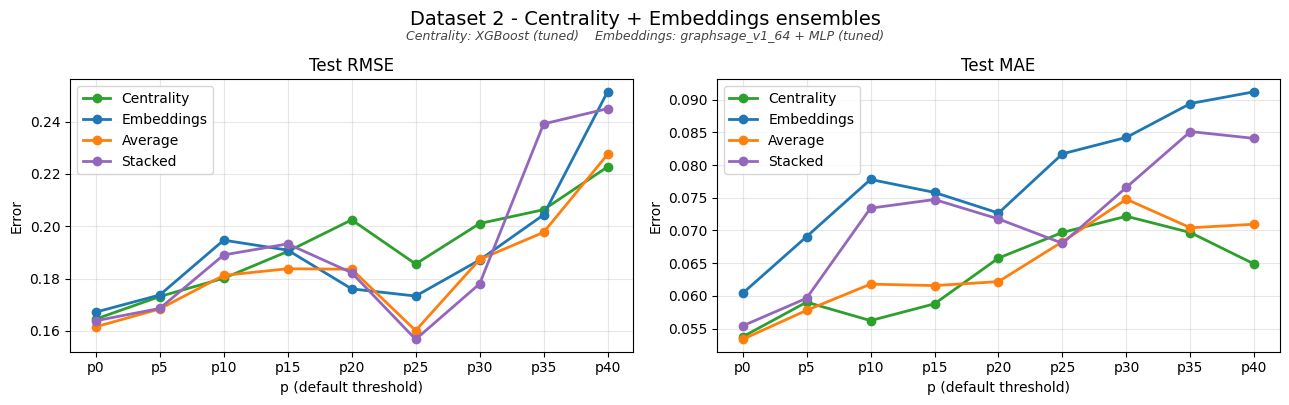

Saved figure: /Users/rubenmarques/Documents/Repositórios/Thesis/src/data/predictions/dataset_2/ensemble/dataset_2_ensemble_comparison.png


,p,best_test_rmse_method,best_test_rmse
0,p0,Average,0.162
1,p5,Average,0.168
2,p10,Centrality,0.180
3,p15,Average,0.184
4,p20,Embeddings,0.176
5,p25,Stacked,0.157
6,p30,Stacked,0.178
7,p35,Average,0.198
8,p40,Centrality,0.223


In [ ]:
# Same colour scheme and plot names/descriptions as Dataset 1's ensemble notebook.
METHOD_COLORS = {
    'Centrality': '#2ca02c',
    'Embeddings': '#1f77b4',
    'Average':    '#ff7f0e',
    'Stacked':    '#9467bd',
}
METHOD_COLS = {
    'Centrality': ('centrality_rmse', 'centrality_mae'),
    'Embeddings': ('embedding_rmse',  'embedding_mae'),
    'Average':    ('average_rmse',    'average_mae'),
    'Stacked':    ('stacked_rmse',    'stacked_mae'),
}
METRIC_PANELS = [(0, 'Test RMSE'), (1, 'Test MAE')]

# The model combination behind each base approach (centrality model | embedding + ML model).
MODEL_DESC = 'Centrality: XGBoost (tuned)     Embeddings: graphsage_v1_64 + MLP (tuned)'


def plot_dataset_ensemble(metrics_df, ds):
    d = metrics_df[metrics_df['dataset'] == ds].set_index('p').loc[P_LIST]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
    for ax, (idx, metric_title) in zip(axes.ravel(), METRIC_PANELS):
        for method, cols in METHOD_COLS.items():
            ax.plot(d.index, d[cols[idx]], marker='o', linewidth=2,
                    label=method, color=METHOD_COLORS[method])
        ax.set_title(metric_title)
        ax.set_xlabel('p (default threshold)')
        ax.set_ylabel('Error')
        ax.grid(True, alpha=0.3)
        ax.legend()
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    fig.suptitle(f'{ds.replace("_", " ").title()} - Centrality + Embeddings ensembles', fontsize=14, y=1.0)
    fig.text(0.5, 0.95, MODEL_DESC, ha='center', va='top', fontsize=9, style='italic', color='#444444')
    out_path = OUT / f'{ds}_ensemble_comparison.png'
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved figure: {out_path}')


def winner_table(metrics_df, ds):
    d = metrics_df[metrics_df['dataset'] == ds].set_index('p').loc[P_LIST]
    rows = []
    for p in P_LIST:
        rmse_by_method = {m: d.loc[p, cols[0]] for m, cols in METHOD_COLS.items()}
        best = min(rmse_by_method, key=rmse_by_method.get)
        rows.append({'p': p, 'best_test_rmse_method': best, 'best_test_rmse': rmse_by_method[best]})
    return pd.DataFrame(rows).round(3)


for ds in DATASETS:
    plot_dataset_ensemble(metrics, ds)
    display(winner_table(metrics, ds))